# Robotics Data Pipelines at Scale with Ray Data

## TLDR

Robotics training data is **multi-camera video plus low-dimensional state and
actions**, and it is large. A single benchmark like LIBERO is hundreds of
thousands of frames across thousands of episodes. You cannot snapshot it onto
every training node. In this notebook you use **Ray Data** to *stream* the
LeRobot v3 dataset straight from HuggingFace, decode video on a CPU worker pool,
and preprocess frames into the layout a policy expects. All of this is done lazily, with
backpressure, and with **no copy of the dataset landing on any node**.

This same streaming pipeline feeds the VLA fine-tuning in notebook 02, the
serving + sim eval in 03, and the world-model pre-training in 04. Learn it once
here.

## Introduction

A LeRobot v3 dataset is a flat table of timestep samples. Each row combines:

- **low-dimensional data** (robot `observation.state`, `action`, timestamps,
  episode/frame indices) stored in chunked **parquet** files, and
- **camera frames** decoded on demand from chunked **mp4** video files.

Episode metadata ties them together: which parquet chunk and which video file
each episode lives in, and the seek timestamp where each episode starts within
its video. Reconstructing a single training row means reading a parquet row
*and* seeking to the right frame in the right mp4 for each camera.

Doing that efficiently across a cluster is the job of a Ray Data
**`Datasource`**. The course ships one, `tools/lerobot_datasource.py`, a single-file,
streaming source for LeRobot v3 layouts that reads from local disk or cloud
storage (`hf://`, `s3://`, `gs://`) with the same code path. We point it at the
public `lerobot/libero` dataset on HuggingFace. NOTE: this datasource will soon be added to open source Ray.

## Key concepts used in this notebook

**Ray Data** is Ray's library for distributed, streaming data processing. It
runs a pipeline of transformations over data that never fully materializes in
memory, applying backpressure so GPU consumers are never overwhelmed and CPU
producers never run too far ahead.

**`Datasource`** is the Ray Data extension point for custom formats. It declares
how to slice a dataset into **read tasks** and how each task turns bytes into
Arrow tables. `LeRobotDatasource` implements this for LeRobot v3.

**Partitioning** is how the dataset is divided into read tasks. The tradeoff is
task count vs. redundant video-file opens. This is covered in Cell 3.

**`map` / `map_batches`** are Ray Data's core transforms. `map` applies a
function per row and `map_batches` applies it to chunks of rows in parallel across
the CPU pool. We use them to rename columns and transpose images.

**Streaming, not snapshotting.** Nothing is downloaded up front. Read tasks pull
parquet + mp4 bytes on demand, decode, and emit batches. The pipeline is
identical whether the dataset is 10 GB or 10 TB.

## What you will learn

- Open a LeRobot v3 dataset over `hf://` and inspect its metadata **without
  reading any frames**
- Compare **partitioning strategies** and their effect on read-task count
- Stream and **preview** a decoded multi-camera frame
- Build a lazy **preprocessing pipeline** with `map` / `map_batches` that
  converts frames into the `(C, H, W)` float32 layout models expect
- Understand why this exact pipeline is reused by notebooks 02, 03, and 04

## Why Ray Data for robotics video?

| Challenge | Without Ray Data | With Ray Data |
|---|---|---|
| Dataset bigger than local disk | Pre-download / shard by hand | **Stream** from `hf://`/`s3://`; nothing lands on disk |
| Mixed parquet + mp4 per row | Custom loader, manual frame seek | `Datasource` resolves both, decodes with PyAV |
| Decode is CPU-bound, training GPU-bound | GPUs stall on data | CPU worker pool decodes ahead with **backpressure** |
| Scale preprocessing independently | Rewrite the loader | Add CPU workers, no code change |
| Mix multiple datasets | Bespoke concatenation | `read_lerobot([...])` / `ds.union(...)` |

## Data flow

```
  hf://datasets/lerobot/libero
            │
   LeRobotDatasource.get_read_tasks(parallelism)
            │  slice into read tasks (by partitioning mode)
            ▼
  ┌──────────────────── read task (CPU worker) ────────────────────┐
  │  parquet rows  ──┐                                             │
  │                  ├─ align by (episode, timestamp) ─▶ frame dict│
  │  mp4 frames  ────┘   (PyAV decode, per camera)                 │
  └────────────────────────────────┬───────────────────────────────┘
            │  .map(rename) .map_batches(transpose)  ← CPU pool, lazy
            ▼
   batches of (C,H,W) float32 images + state + action  ──▶ trainers (02/04)
```

## Cell 1: Connect to Ray

**What you do:** connect to the cluster and ship the working directory (so the
`lerobot_datasource` module is importable on every read-task worker).

**What to check:** you should see the cluster's GPUs and CPUs. Data
preprocessing here is CPU-bound. Note that the GPUs stay idle until notebook 02.

**Why it matters:** `runtime_env={"working_dir": "."}` is what lets Ray Data's
distributed read tasks import our custom `Datasource` on remote workers.

In [1]:
import os
import numpy as np
import ray

# This tutorial reads ALL data from a PUBLIC S3 mirror instead of Hugging Face, so that
# hundreds of concurrent attendee clusters can't be throttled by HF. Two env vars make
# that work; they must be set BEFORE importing the datasource AND shipped to every Ray
# Data read worker (via runtime_env below):
#   LEROBOT_S3_ANON=1  -> datasource reads the public bucket UNSIGNED (works from any
#                         AWS account/region, no credentials needed)
#   HF_HUB_OFFLINE=1   -> guarantees no accidental Hugging Face network call at runtime
os.environ["LEROBOT_S3_ANON"] = "1"
os.environ["HF_HUB_OFFLINE"] = "1"

from tools.lerobot_datasource import LeRobotDatasource, Partitioning

env_vars = {
    "LEROBOT_S3_ANON":           "1",
    "HF_HUB_OFFLINE":            "1",
    "HF_HUB_ENABLE_HF_TRANSFER": "1",
    "HF_HUB_DOWNLOAD_TIMEOUT":   "60",   # generous timeout for concurrent parquet/video reads
}

ray.init(
    address="auto",
    runtime_env={"working_dir": ".", "env_vars": env_vars},
    ignore_reinit_error=True,
)

# Quiet Ray Data's per-stage progress/INFO logs for readable notebook output.
import logging
logging.getLogger("ray.data").setLevel(logging.WARNING)
logging.getLogger("openlineage").setLevel(logging.WARNING)
logging.getLogger("huggingface_hub.utils._http").setLevel(logging.ERROR)
ray.data.DataContext.get_current().enable_progress_bars = False

from tools import cluster
cluster.describe()   # whatever shape the cluster is; this notebook is CPU-bound

2026-08-18 18:13:36,610	INFO worker.py:1821 -- Connecting to existing Ray cluster at address: 10.0.25.129:6379...
2026-08-18 18:13:36,623	INFO worker.py:1998 -- Connected to Ray cluster. View the dashboard at https://session-ydm8d952sa7tfrb1pgp99yik1u.i.anyscaleuserdata.com 
2026-08-18 18:13:36,628	INFO packaging.py:392 -- Ignoring upload to cluster for these files: [PosixPath('/home/ray/default/ray_summit_robotics_2026/.gitignore')]
2026-08-18 18:13:36,704	INFO packaging.py:691 -- Creating a file package for local module '.'.
2026-08-18 18:13:36,706	INFO packaging.py:392 -- Ignoring upload to cluster for these files: [PosixPath('/home/ray/default/ray_summit_robotics_2026/.gitignore')]
2026-08-18 18:13:36,723	WARNING packaging.py:516 -- File /home/ray/default/ray_summit_robotics_2026/.git/objects/pack/pack-79b1f5bff7065115c34c6764c9f745e4f453b2b0.pack is very large (27.94MiB). Consider adding this file to the 'excludes' list to skip uploading it: `ray.init(..., runtime_env={'excludes':

Cluster: 2 GPU(s) (T4) across 2 GPU node(s), 16 CPUs total
  ip-10-0-27-101: 1 x T4, 8 CPU, 19 GiB Ray memory
  ip-10-0-31-98: 1 x T4, 8 CPU, 19 GiB Ray memory
Derived: train workers = 2, sim workers (nb03) = 1


/home/ray/anaconda3/lib/python3.11/site-packages/ray/_private/worker.py:2046: FutureWarning: Tip: In future versions of Ray, Ray will no longer override accelerator visible devices env var if num_gpus=0 or num_gpus=None (default). To enable this behavior and turn off this error message, set RAY_ACCEL_ENV_VAR_OVERRIDE_ON_ZERO=0
  warnings.warn(


{'gpus': 2,
 'cpus': 16,
 'nodes': 3,
 'gpu_nodes': 2,
 'accelerator': 'T4',
 'per_node': [{'host': 'ip-10-0-27-101',
   'gpus': 1,
   'cpus': 8,
   'memory_gib': 18.90000000037253,
   'accelerator': 'T4'},
  {'host': 'ip-10-0-31-98',
   'gpus': 1,
   'cpus': 8,
   'memory_gib': 18.90000000037253,
   'accelerator': 'T4'}]}

## Cell 2: Open the dataset and inspect metadata

**What you do:** construct a `LeRobotDatasource` pointed at `lerobot/libero` on
HuggingFace and read its metadata.

**What to check:** `~1,693` episodes / `~273k` frames, two cameras
(`observation.images.image`, `observation.images.image2`), an 8-D state and a
7-D action. None of these required reading a single video frame as only the small
`meta/` files were fetched.

**Why it matters:** metadata (`stats`, feature shapes, episode index) is loaded
eagerly and cheaply on the driver and all heavy I/O is deferred to read tasks. This
is what makes "open a 10 TB dataset" instant.

In [2]:
# Public S3 mirror of lerobot/libero (full LeRobot v3 layout). The datasource treats
# s3:// exactly like hf:// 
HF_DATASET_URI = "s3://anyscale-public-materials-use2/ray_summit_robotics_2026/libero"
source = LeRobotDatasource(HF_DATASET_URI)
meta = source.meta

print(f"Episodes   : {meta.total_episodes:,}")
print(f"Frames     : {meta.total_frames:,}")
print(f"Cameras    : {meta.video_keys}")
print(f"FPS        : {meta.info['fps']}")
print(f"State dim  : {np.asarray(meta.stats['observation.state']['mean']).shape}")
print(f"Action dim : {np.asarray(meta.stats['action']['mean']).shape}")

Episodes   : 1,693
Frames     : 273,465
Cameras    : ['observation.images.image', 'observation.images.image2']
FPS        : 10.0
State dim  : (8,)
Action dim : (7,)


## Cell 3: Partitioning: how the dataset becomes read tasks

**What you do:** ask the datasource to *plan* its read tasks under four
partitioning strategies. `plan()` is pure computation over the episode metadata. There is **no I/O** so this is instant.

**What to check:** the same 273k frames split into very different task counts:
`sequential` → 1 task (minimal memory), `file_group`/`chain` → one task per
shared video-file group (balanced is the default), `episode` → one task per
episode (maximum parallelism, but the same mp4 may be opened by several tasks).

**Why it matters:** partitioning is the knob that trades parallelism against
redundant video-file opens. On a small local dataset you might maximize task
count, while on a large cloud dataset you minimize file opens. It's the same data, same code, and
one argument.

In [3]:
for mode in ("sequential", "file_group", "episode"):
    s = LeRobotDatasource(HF_DATASET_URI, partitioning=mode)
    plan = s.plan(parallelism=0)   # 0 = one task per natural slice (no merging)
    print(f"{mode:12} -> {len(plan):5d} read tasks")

sequential   ->     1 read tasks
file_group   ->    37 read tasks
episode      ->  1693 read tasks


## Cell 4: Stream and preview a frame

**What you do:** read exactly one row through the datasource and visualize both
camera views plus the raw state/action vectors.

**What to check:** two RGB frames render, and you see an 8-D state and 7-D
action. This is the first time any video is actually decoded. `take(1)` pulls
just enough bytes to produce one row.

**Why it matters:** it confirms the full path works end to end: parquet row +
mp4 seek + PyAV decode + Arrow assembly, streamed from HuggingFace with nothing
cached locally.


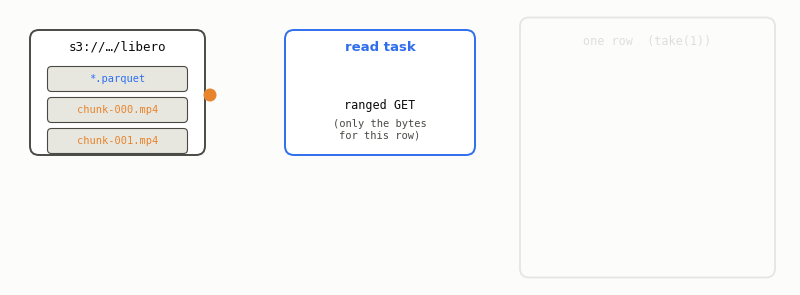

INFO:openlineage.client.client:OpenLineageClient will use `composite` transport
INFO:openlineage.client.transport.composite:Stopping OpenLineage CompositeTransport emission after the first successful delivery because `continue_on_success=False`. Transport that emitted the event: <HttpTransport(name=first, kind=http, priority=1)>


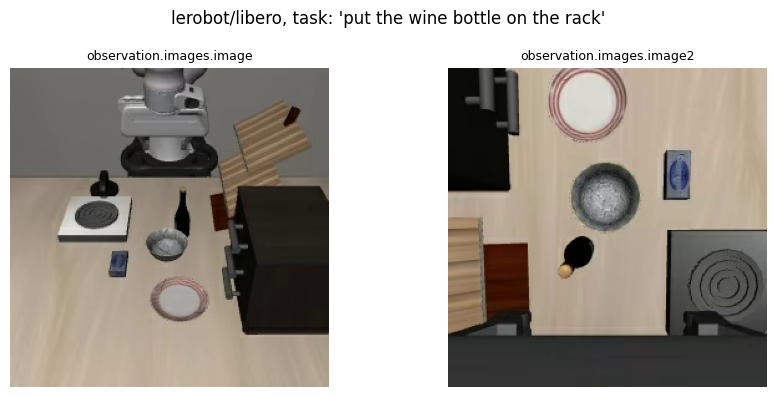

state : [-1.81650281e-01  1.07182255e-02  1.18458176e+00  3.13815260e+00
  1.59036578e-03 -1.10764228e-01  3.87840532e-02 -3.87918055e-02]
action: [ 0.49017859  0.14464286  0.13660714 -0.08142857  0.24321428  0.04178571
 -1.        ]


In [4]:
%matplotlib inline
import matplotlib.pyplot as plt

from tools.viz import show_gif
show_gif("assets/nb01_cell4.gif",
         caption="take(1): ranged S3 reads -> video decode -> one assembled row")

row = ray.data.read_datasource(source).take(1)[0]

axes = np.atleast_1d(plt.subplots(1, len(meta.video_keys), figsize=(9, 4))[1])
for ax, cam in zip(axes, meta.video_keys):
    ax.imshow(np.asarray(row[cam]))
    ax.set_title(cam, fontsize=9)
    ax.axis("off")
plt.suptitle(f"lerobot/libero, task: {row.get('task', '?')!r}")
plt.tight_layout()
plt.show()

print("state :", np.asarray(row["observation.state"]))
print("action:", np.asarray(row["action"]))

## Cell 5: Build the preprocessing pipeline

**What you do:** define two transforms and compose them into a lazy Ray Data
pipeline:
- `rename_columns` (a `map`) is a no-op here because LIBERO's camera names need no
  remap, but the hook is where you'd align differing camera key conventions.
- `transpose_images` (a `map_batches`) converts decoded `HWC uint8` frames into
  the `CHW float32` layout the policy and the world-model encoder expect.

**What to check:** `build_libero_dataset()` returns immediately and prints a
lazy `Dataset` plan. **Nothing has executed yet** as Ray Data only runs the
transforms when a consumer pulls batches.

**Why it matters:** this is the *exact* pipeline notebooks 02 and 03 feed to
the trainer, and `transpose_images` handles both LIBERO frames and the sim
trajectory frames merged in during the closed loop. One transform, every source.

In [5]:
CAMERA_RENAME = {}                                   # LIBERO names need no remap
IMAGE_KEYS = [CAMERA_RENAME.get(k, k) for k in meta.video_keys]


def rename_columns(row, rename):
    return {rename.get(k, k): v for k, v in row.items()}


def transpose_images(batch, camera_keys):
    """HWC -> CHW, staying uint8. Handles both LIBERO and sim frames.

    The float32 cast deliberately does NOT happen here. A 256x256x3 frame is
    197 KB as uint8 and 786 KB as float32, and the datasource sizes its blocks
    from `estimated_row_size_bytes`, which counts video frames as uint8 (~341
    rows per 128 MB block). Casting inside the pipeline made every block 4x
    larger than the streaming executor believed it to be, so on a 32 GB node
    the queued blocks overran host RAM and the OOM killer took out the raylet.
    util.NumpyToTorchCollate(..., image_keys=IMAGE_KEYS) widens to float32 on
    the GPU instead, where the tensor is transient.
    """
    out = dict(batch)
    for key in camera_keys:
        out[key] = np.transpose(np.stack(list(batch[key])), (0, 3, 1, 2))
    return out


def build_libero_dataset():
    return (
        ray.data.read_datasource(source)
        .map(rename_columns, fn_args=(CAMERA_RENAME,))
        .map_batches(transpose_images, batch_size=32, fn_args=(IMAGE_KEYS,))
    )


libero_ds = build_libero_dataset()
print(libero_ds)


MapBatches(transpose_images)
+- Map(rename_columns)
   +- Dataset(
         num_rows=273465,
         schema={
            observation.state: list<element: float>,
            action: list<element: float>,
            timestamp: float,
            frame_index: int64,
            episode_index: int64,
            index: int64,
            task_index: int64,
            observation.i...: ArrowVariableShapedTensorType(ndim=3, dtype=uint8),
            observation.i...: ArrowVariableShapedTensorType(ndim=3, dtype=uint8),
            task: string,
            dataset_index: int32
         }
      )


## Cell 6: Materialize one batch to confirm shapes

**What you do:** pull two preprocessed rows. *Now* the pipeline runs: read →
rename → transpose.

**What to check:** image columns are `(B, 3, H, W)` `float32` (CHW). The
`state` / `action` columns arrive as **object arrays of per-row vectors**
(they're variable-length list columns in parquet); stacking them yields
`(B, 8)` and `(B, 7)`. The trainer's collate function (notebook 02) does exactly
this stacking on the way to the GPU.

**Why it matters:** it proves the CPU-side boundary is clean since the GPU side
receives fixed-shape, model-ready tensors and never touches video decoding.

In [6]:
batch = libero_ds.take_batch(2)
for k, v in batch.items():
    arr = np.asarray(v)
    if arr.dtype == object:                       # variable-length list column
        arr = np.stack([np.asarray(x) for x in v])  # ...stack as the collate does
    print(f"{k:32s} shape={str(arr.shape):20s} dtype={arr.dtype}")

INFO:openlineage.client.client:OpenLineageClient will use `composite` transport
INFO:openlineage.client.transport.composite:Stopping OpenLineage CompositeTransport emission after the first successful delivery because `continue_on_success=False`. Transport that emitted the event: <HttpTransport(name=first, kind=http, priority=1)>


observation.state                shape=(2, 8)               dtype=float64
action                           shape=(2, 7)               dtype=float64
timestamp                        shape=(2,)                 dtype=float64
frame_index                      shape=(2,)                 dtype=int64
episode_index                    shape=(2,)                 dtype=int64
index                            shape=(2,)                 dtype=int64
task_index                       shape=(2,)                 dtype=int64
observation.images.image         shape=(2, 3, 256, 256)     dtype=uint8
observation.images.image2        shape=(2, 3, 256, 256)     dtype=uint8
task                             shape=(2,)                 dtype=<U86
dataset_index                    shape=(2,)                 dtype=int64


(autoscaler +2m43s) Tip: use `ray status` to view detailed cluster status. To disable these messages, set RAY_SCHEDULER_EVENTS=0.
(raylet) WARNING: 4 PYTHON worker processes have been started on node: 5934124326c2e015297a7e4646fbedde738e9de1d1210d77cf0d54a2 with address: 10.0.25.129. This could be a result of using a large number of actors, or due to tasks blocked in ray.get() calls (see https://github.com/ray-project/ray/issues/3644 for some discussion of workarounds).
(raylet) WARNING: 6 PYTHON worker processes have been started on node: 5934124326c2e015297a7e4646fbedde738e9de1d1210d77cf0d54a2 with address: 10.0.25.129. This could be a result of using a large number of actors, or due to tasks blocked in ray.get() calls (see https://github.com/ray-project/ray/issues/3644 for some discussion of workarounds).


## Conclusion

You streamed a 273k-frame multi-camera robotics dataset directly from
HuggingFace with **Ray Data**, inspected its metadata for free,
compared partitioning strategies, previewed decoded frames, and built a lazy
`map` / `map_batches` preprocessing pipeline that emits model-ready tensors.

**Ray primitives used:** `ray.data.read_datasource`, a custom `Datasource`
(`LeRobotDatasource`), `.map`, `.map_batches`.

**Scaling levers:** more CPU workers → faster decode (no code change);
partitioning mode → parallelism vs. file-open tradeoff; `read_lerobot([...])` /
`.union(...)` → mix multiple datasets.

Next, **`02_vla_finetuning.ipynb`** hands this exact pipeline to **Ray Train**
to fine-tune the 3.4B-parameter PI0.5 policy across every GPU in the cluster.